In [63]:
import pandas as pd
import requests
import os
from dotenv import load_dotenv
import time

load_dotenv()

# Iloilo City Coords & Timeline
lat, lon = 10.7019, 122.5622
start_year = 2016 # NSRDB data starts from 2016
end_year = 2020 # 2020 to respect PVGIS-ERA5 database limits

print(f"Downloading PVGIS data ({start_year}-{end_year})...")
url_pvgis = f"https://re.jrc.ec.europa.eu/api/v5_2/seriescalc?lat={lat}&lon={lon}&startyear={start_year}&endyear={end_year}&raddatabase=PVGIS-ERA5&pvcalculation=1&peakpower=1&loss=14&outputformat=csv"
response_pvgis = requests.get(url_pvgis)

if response_pvgis.status_code == 200:
    with open(f'../data/raw/pvgis_{start_year}_{end_year}.csv', 'wb') as f:
        f.write(response_pvgis.content)
    print("PVGIS data saved successfully.")
else:
    print(f"PVGIS Download Failed: {response_pvgis.status_code}")
    print(f"Error Details: {response_pvgis.text}")

PVGIS data saved successfully.


In [64]:
print("\nDownloading NSRDB Himawari data...")
api_key = os.getenv("NREL_API_KEY")
email = os.getenv("NREL_EMAIL")
attributes = "ghi,dni,dhi,air_temperature,wind_speed,relative_humidity"

for year in range(start_year, end_year + 1):
    print(f"Fetching NSRDB data for {year}...")
    
    url_nsrdb = f"https://developer.nrel.gov/api/nsrdb/v2/solar/himawari-download.csv?api_key={api_key}&wkt=POINT({lon} {lat})&names={year}&interval=60&utc=false&email={email}&attributes={attributes}&leap_day=true"
    
    response_nsrdb = requests.get(url_nsrdb)
    
    if response_nsrdb.status_code == 200:
        with open(f'../data/raw/nsrdb_{year}.csv', 'wb') as f:
            f.write(response_nsrdb.content)
        print(f"NSRDB {year} saved.")
    else:
        print(f"Failed NSRDB {year}. Status: {response_nsrdb.status_code}.")
        print(f"Error Details: {response_nsrdb.text}")
    
    time.sleep(2) 

print("\nNSRDB Data acquisition complete. Check the ../data/raw/ folder.")


Fetching NSRDB data for 2016...
NSRDB 2016 saved.
Fetching NSRDB data for 2017...
NSRDB 2017 saved.
Fetching NSRDB data for 2018...
NSRDB 2018 saved.
Fetching NSRDB data for 2019...
NSRDB 2019 saved.
Fetching NSRDB data for 2020...
NSRDB 2020 saved.

NSRDB Data acquisition complete. Check the ../data/raw/ folder.


Loading and Concatenating NSRDB (features) and PVGIS (target) data

Loading PVGIS Data (Target)...


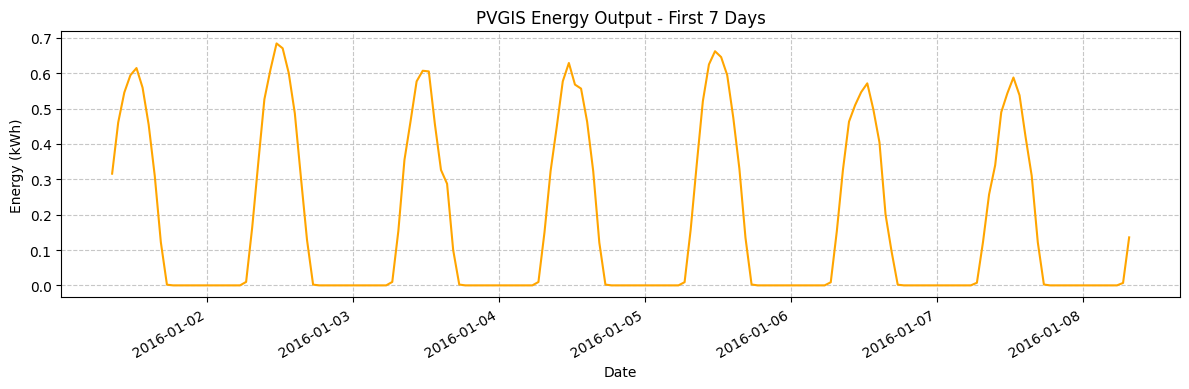

Loading & Stitching NSRDB Data (Features)...


In [65]:
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

figures_dir = '../figures'

print("Loading PVGIS Data (Target)...")
# skip first 10 metadata rows
pvgis = pd.read_csv('../data/raw/pvgis_2016_2020.csv', skiprows=10)
pvgis['datetime'] = pd.to_datetime(pvgis['time'], format='%Y%m%d:%H%M', errors='coerce')
# Drop rows that couldn't be parsed as dates
pvgis = pvgis.dropna(subset=['datetime'])
pvgis.set_index('datetime', inplace=True)
pvgis['P'] = pd.to_numeric(pvgis['P'], errors='coerce')
pvgis['energy_kwh'] = pvgis['P'] / 1000 #convert Watts to kWh

pvgis.index = pvgis.index + pd.Timedelta(hours=8)


#visualization of the first 7 days of PVGIS energy output
plt.figure(figsize=(12, 4))
pvgis['energy_kwh'].head(24*7).plot(color='orange')
plt.title('PVGIS Energy Output - First 7 Days')
plt.ylabel('Energy (kWh)')
plt.xlabel('Date')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig(f'{figures_dir}/pvgis_first_week.png', dpi=300, bbox_inches='tight')
plt.show()


print("Loading & Stitching NSRDB Data (Features)...")
nsrdb_files = sorted(glob('../data/raw/nsrdb_*.csv'))
nsrdb_list = []

for file in nsrdb_files:
    # skip first 2 metadata rows
    df_temp = pd.read_csv(file, skiprows=2)
    nsrdb_list.append(df_temp)

# Combine all years into one dataframe
nsrdb = pd.concat(nsrdb_list, ignore_index=True)
nsrdb['datetime'] = pd.to_datetime(nsrdb[['Year', 'Month', 'Day', 'Hour', 'Minute']])
nsrdb.set_index('datetime', inplace=True)

Merging & Engineering Features

In [66]:
pvgis_aligned = pvgis[['energy_kwh']].resample('h').interpolate(method='time')
df = nsrdb.merge(pvgis_aligned, left_index=True, right_index=True, how='inner')

In [67]:
df['hour'] = df.index.hour
df['month'] = df.index.month
df['is_wet_season'] = df['month'].between(6, 11).astype(int)

features = ['GHI', 'DNI', 'DHI', 'Temperature', 'Wind Speed', 'Relative Humidity', 'hour', 'month', 'is_wet_season']
df = df.dropna()
X = df[features].values
y = df[['energy_kwh']].values

print(f"Total dataset shape: {df.shape[0]} hourly records.")

Total dataset shape: 43839 hourly records.


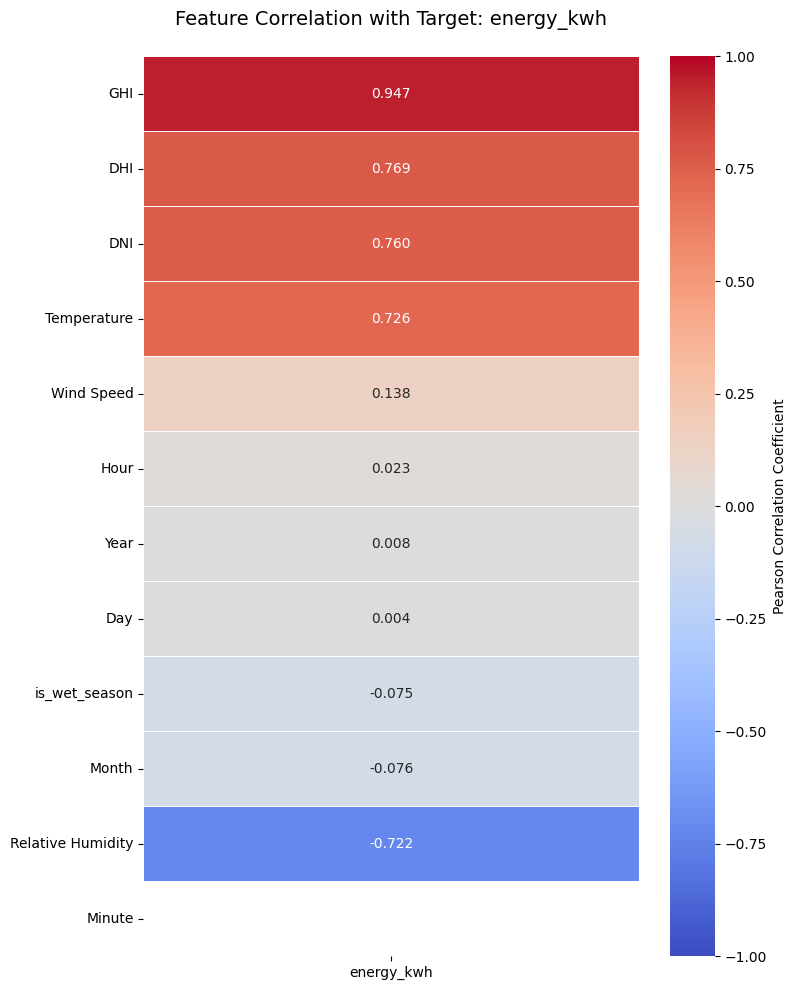

In [68]:
def plot_target_correlation(df, target_col, figsize=(8, 10)):
    
    corr_matrix = df.corr()
    
    target_corr = corr_matrix[[target_col]].drop(target_col).sort_values(by=target_col, ascending=False)
    
    plt.figure(figsize=figsize)
    
    sns.heatmap(target_corr, 
                annot=True,
                fmt=".3f",
                cmap='coolwarm',
                vmin=-1, vmax=1,
                linewidths=0.5,
                cbar_kws={'label': 'Pearson Correlation Coefficient'})
    
    plt.title(f'Feature Correlation with Target: {target_col}\n', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{figures_dir}/Feature_Correlation_{target_col}.png', dpi=300, bbox_inches='tight')
    plt.show()

feature_cols = [
    'Year', 'Month', 'Day', 'Hour', 'Minute', 
    'GHI', 'DNI', 'DHI', 'Temperature', 
    'Wind Speed', 'Relative Humidity', 'is_wet_season'
]

target_col = 'energy_kwh' 

cols_to_correlate = feature_cols + [target_col]

plot_target_correlation(df[cols_to_correlate], target_col=target_col, figsize=(8, 10))

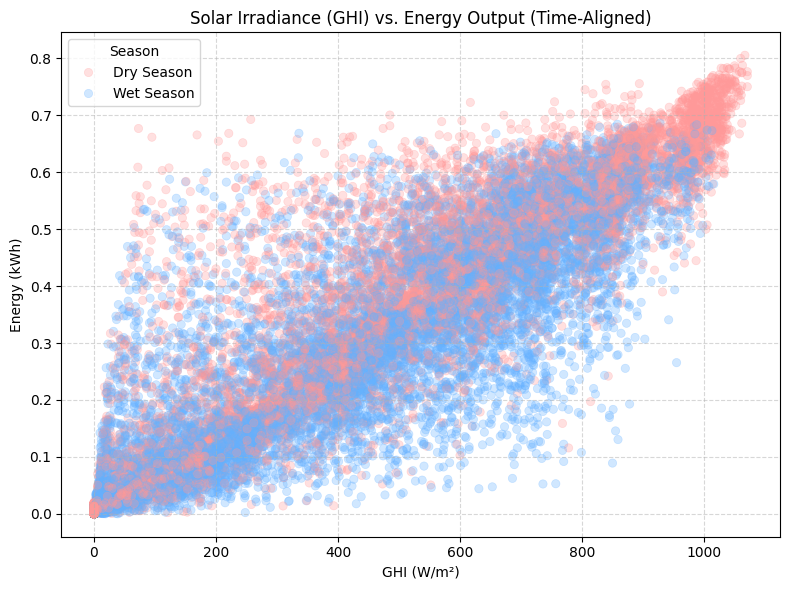

In [69]:
df['Season'] = df['is_wet_season'].map({0: 'Dry Season', 1: 'Wet Season'})

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='GHI', y='energy_kwh', hue='Season', 
                palette={'Dry Season': '#FF9999', 'Wet Season': '#66B2FF'}, 
                alpha=0.3, edgecolor=None)

plt.title('Solar Irradiance (GHI) vs. Energy Output (Time-Aligned)')
plt.xlabel('GHI (W/m²)')
plt.ylabel('Energy (kWh)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

plt.savefig(f'{figures_dir}/ghi_vs_energy_scatter_fixed.png', dpi=300, bbox_inches='tight')
plt.show()

df.drop(columns=['Season'], inplace=True)

Chronological Split (70/15/15)

In [70]:
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val     = X[train_end:val_end], y[train_end:val_end]
X_test, y_test   = X[val_end:], y[val_end:]

Scaling Data

In [71]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np


continuous_features = ['GHI', 'DNI', 'DHI', 'Temperature', 'Wind Speed', 'Relative Humidity']
categorical_features = ['hour', 'month', 'is_wet_season']

X_train_cont = X_train[:, :6]
X_train_cat  = X_train[:, 6:]

X_val_cont = X_val[:, :6]
X_val_cat  = X_val[:, 6:]

X_test_cont = X_test[:, :6]
X_test_cat  = X_test[:, 6:]

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_cont_scaled = scaler_X.fit_transform(X_train_cont)
y_train_scaled      = scaler_y.fit_transform(y_train)

X_val_cont_scaled  = scaler_X.transform(X_val_cont)
y_val_scaled       = scaler_y.transform(y_val)

X_test_cont_scaled = scaler_X.transform(X_test_cont)
y_test_scaled      = scaler_y.transform(y_test)

X_train_scaled = np.hstack((X_train_cont_scaled, X_train_cat))
X_val_scaled   = np.hstack((X_val_cont_scaled, X_val_cat))
X_test_scaled  = np.hstack((X_test_cont_scaled, X_test_cat))

Saving Processed Data & Scalers

In [72]:
import numpy as np
import joblib

#arrays
np.save('../data/processed/X_train.npy', X_train_scaled)
np.save('../data/processed/y_train.npy', y_train_scaled)
np.save('../data/processed/X_val.npy', X_val_scaled)
np.save('../data/processed/y_val.npy', y_val_scaled)
np.save('../data/processed/X_test.npy', X_test_scaled)
np.save('../data/processed/y_test.npy', y_test_scaled)

#scalers
joblib.dump(scaler_X, '../models/scaler_X.save')
joblib.dump(scaler_y, '../models/scaler_y.save')

['../models/scaler_y.save']